In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

FILE_PATH = r"/content/Study Case for Univ Airlangga 2026 _Actuarial AXA (Sent 2026.05.26).xlsx"

viridis_3 = sns.color_palette("viridis", 3)
viridis_6 = sns.color_palette("viridis", 6)
viridis_10 = sns.color_palette("viridis", 10)

In [ ]:
def load_data(filepath):

    premium = pd.read_excel(
        filepath,
        sheet_name="Raw Premium",
        parse_dates=["DT_INC", "DT_END"]
    )

    claim = pd.read_excel(
        filepath,
        sheet_name="Raw Claim",
        parse_dates=["DT_CLM"]
    )

    return premium, claim

In [ ]:
def create_derived_variables(premium, claim):

    premium = premium.copy()
    claim = claim.copy()

    premium["UW_YEAR"] = premium["DT_INC"].dt.year

    premium["NWP_IDR"] = (
        premium["GWP_IDR"]
        - premium["RWP_IDR"]
    )

    claim["CLM_YEAR"] = claim["DT_CLM"].dt.year

    claim["GROSS_INCURRED"] = (
        claim["GRS_ST_IDR"].fillna(0)
        + claim["GRS_OS_IDR"].fillna(0)
    )

    claim["NET_INCURRED"] = (
        (claim["GRS_ST_IDR"].fillna(0)
         - claim["RI_ST_IDR"].fillna(0))
        +
        (claim["GRS_OS_IDR"].fillna(0)
         - claim["RI_OS_IDR"].fillna(0))
    )

    return premium, claim

In [ ]:
def premium_trend_analysis(premium):

    premium_trend = (
        premium.groupby("UW_YEAR")
        .agg(
            GWP_IDR=("GWP_IDR", "sum"),
            RWP_IDR=("RWP_IDR", "sum"),
            NWP_IDR=("NWP_IDR", "sum"),
            POLICY_COUNT=("POLICY_NO", "nunique")
        )
        .reset_index()
    )

    premium_trend["CESSION_RATE"] = (
        premium_trend["RWP_IDR"]
        / premium_trend["GWP_IDR"]
    )

    premium_trend["GWP_YOY"] = (
        premium_trend["GWP_IDR"]
        .pct_change()
    )

    return premium_trend

In [ ]:
def claim_trend_analysis(claim):

    claim_trend = (
        claim.groupby("CLM_YEAR")
        .agg(
            GROSS_INCURRED=("GROSS_INCURRED", "sum"),
            NET_INCURRED=("NET_INCURRED", "sum"),
            CLAIM_COUNT=("CLM_REF", "nunique")
        )
        .reset_index()
    )

    claim_trend["CLAIM_SEVERITY"] = (
        claim_trend["GROSS_INCURRED"]
        / claim_trend["CLAIM_COUNT"]
    )

    return claim_trend

In [ ]:
def claim_frequency_analysis(
    premium,
    claim
):

    policy_count = (
        premium.groupby("UW_YEAR")["POLICY_NO"]
        .nunique()
    )

    claim_count = (
        claim.groupby("CLM_YEAR")["CLM_REF"]
        .nunique()
    )

    freq = pd.DataFrame({
        "POLICIES": policy_count,
        "CLAIMS": claim_count
    })

    freq = freq.fillna(0)

    freq["CLAIM_FREQUENCY"] = (
        freq["CLAIMS"]
        / freq["POLICIES"]
    )

    return freq.reset_index()

In [ ]:
def loss_ratio_analysis(
    premium_trend,
    claim_trend
):

    lr = premium_trend.merge(
        claim_trend,
        left_on="UW_YEAR",
        right_on="CLM_YEAR",
        how="left"
    )

    lr["GROSS_LR"] = (
        lr["GROSS_INCURRED"]
        / lr["GWP_IDR"]
    )

    lr["NET_LR"] = (
        lr["NET_INCURRED"]
        / lr["NWP_IDR"]
    )

    return lr

In [ ]:
def cob_loss_ratio_analysis(
    premium,
    claim
):

    policy_map = premium[
        ["POLICY_NO", "UW_YEAR", "COB"]
    ].drop_duplicates()

    claim_uw = claim.merge(
        policy_map,
        on="POLICY_NO",
        how="inner",
        suffixes=("_claim", "")
    )

    premium_cob = (
        premium.groupby(
            ["UW_YEAR", "COB"]
        )
        .agg(
            GWP=("GWP_IDR", "sum")
        )
        .reset_index()
    )

    claim_cob = (
        claim_uw.groupby(
            ["UW_YEAR", "COB"]
        )
        .agg(
            GROSS_INCURRED=("GROSS_INCURRED", "sum")
        )
        .reset_index()
    )

    cob_lr = premium_cob.merge(
        claim_cob,
        on=["UW_YEAR", "COB"],
        how="left"
    )

    cob_lr["GROSS_INCURRED"] = (
        cob_lr["GROSS_INCURRED"]
        .fillna(0)
    )

    cob_lr["GROSS_LR"] = (
        cob_lr["GROSS_INCURRED"]
        / cob_lr["GWP"]
    )

    return cob_lr

In [ ]:
def validation_tables(
    premium_trend,
    claim_trend,
    lr
):

    print("\nPREMIUM SUMMARY")

    display_df = premium_trend.copy()

    for col in [
        "GWP_IDR",
        "RWP_IDR",
        "NWP_IDR"
    ]:
        display_df[col] /= 1e9

    print(display_df.round(2))

    print("\nCLAIM SUMMARY")

    display_df = claim_trend.copy()

    for col in [
        "GROSS_INCURRED",
        "NET_INCURRED",
        "CLAIM_SEVERITY"
    ]:
        display_df[col] /= 1e9

    print(display_df.round(2))

    print("\nLOSS RATIO")

    display_df = lr[
        ["UW_YEAR", "GROSS_LR", "NET_LR"]
    ].copy()

    display_df["GROSS_LR"] *= 100
    display_df["NET_LR"] *= 100

    print(display_df.round(2))

In [ ]:
def generate_insights(lr, claim_trend):

    print("\n===== INSIGHTS =====")

    worst_year = (
        lr.loc[
            lr["GROSS_LR"].idxmax()
        ]
    )

    best_year = (
        lr.loc[
            lr["GROSS_LR"].idxmin()
        ]
    )

    print(
        f"Worst UW Year: "
        f"{int(worst_year['UW_YEAR'])}"
    )

    print(
        f"Best UW Year: "
        f"{int(best_year['UW_YEAR'])}"
    )

    highest_severity = (
        claim_trend.loc[
            claim_trend[
                "CLAIM_SEVERITY"
            ].idxmax()
        ]
    )

    print(
        f"Highest Claim Severity: "
        f"{int(highest_severity['CLM_YEAR'])}"
    )

    print(
        "UW Year 2023 belum mature "
        "karena claim development masih berlangsung."
    )

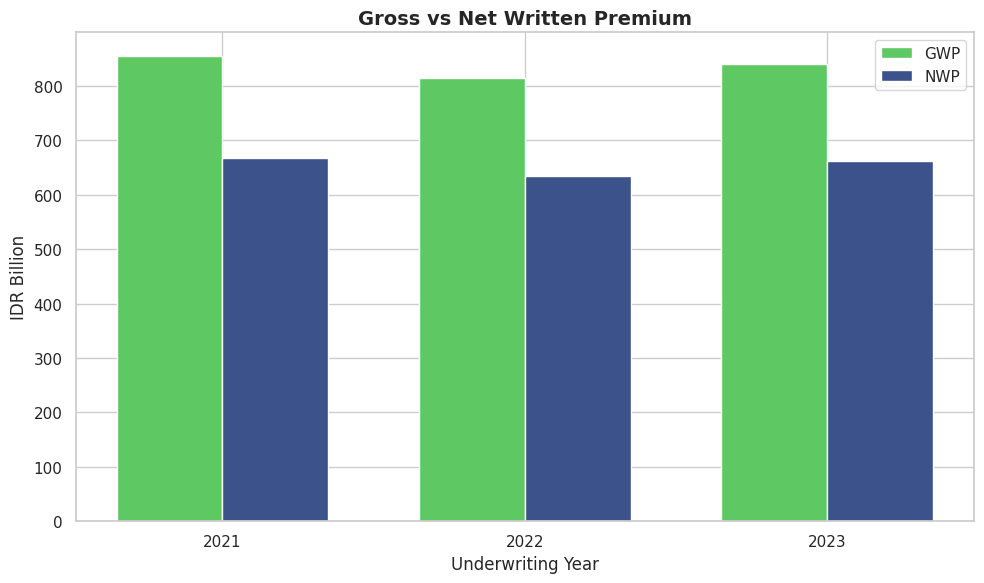

In [ ]:
# =====================================================
# PLOT 1
# PREMIUM TREND
# =====================================================

plt.figure(figsize=(10,6))

x = np.arange(len(premium_trend))
width = 0.35

plt.bar(
    x - width/2,
    premium_trend["GWP_IDR"]/1e9,
    width,
    color=viridis_3[2],
    label="GWP"
)

plt.bar(
    x + width/2,
    premium_trend["NWP_IDR"]/1e9,
    width,
    color=viridis_3[0],
    label="NWP"
)

plt.xticks(
    x,
    premium_trend["UW_YEAR"].astype(int)
)

plt.title(
    "Gross vs Net Written Premium",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Underwriting Year")
plt.ylabel("IDR Billion")

plt.legend()

plt.tight_layout()
plt.show()

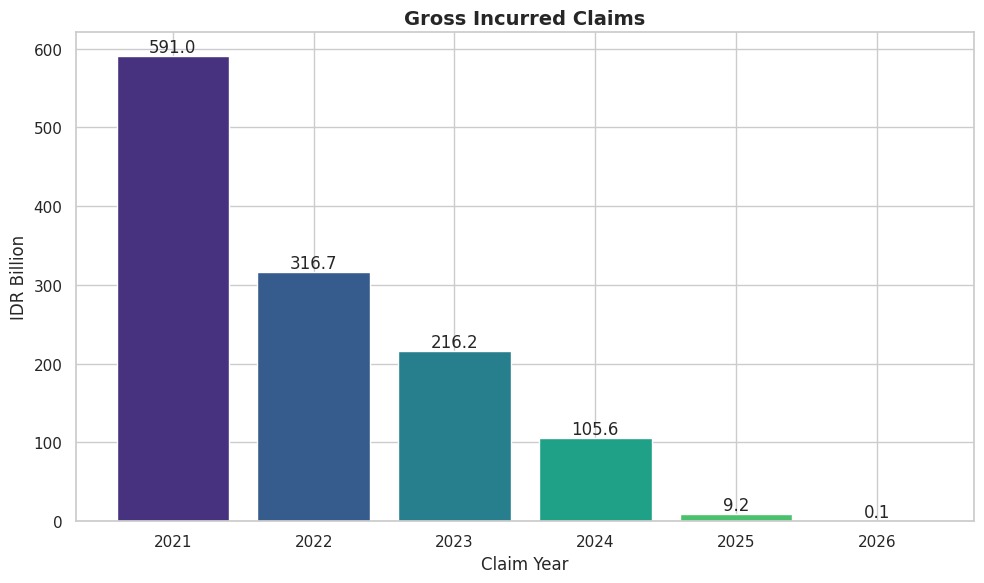

In [ ]:
# =====================================================
# PLOT 2
# CLAIM TREND
# =====================================================

plt.figure(figsize=(10,6))

bars = plt.bar(
    claim_trend["CLM_YEAR"].astype(int),
    claim_trend["GROSS_INCURRED"]/1e9,
    color=viridis_6
)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}",
        ha="center",
        va="bottom"
    )

plt.xticks(
    claim_trend["CLM_YEAR"].astype(int)
)

plt.title(
    "Gross Incurred Claims",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Claim Year")
plt.ylabel("IDR Billion")

plt.tight_layout()
plt.show()

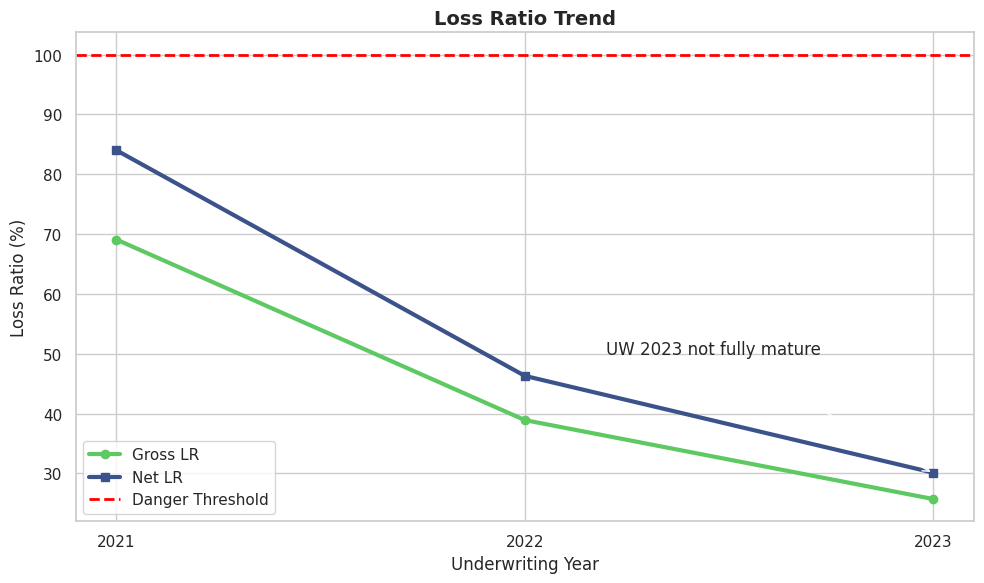

In [ ]:
# =====================================================
# PLOT 3
# LOSS RATIO TREND
# =====================================================

plt.figure(figsize=(10,6))

plt.plot(
    lr["UW_YEAR"].astype(int),
    lr["GROSS_LR"]*100,
    marker="o",
    linewidth=3,
    color=viridis_3[2],
    label="Gross LR"
)

plt.plot(
    lr["UW_YEAR"].astype(int),
    lr["NET_LR"]*100,
    marker="s",
    linewidth=3,
    color=viridis_3[0],
    label="Net LR"
)

plt.axhline(
    100,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Danger Threshold"
)

plt.xticks(
    lr["UW_YEAR"].astype(int)
)

plt.title(
    "Loss Ratio Trend",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Underwriting Year")
plt.ylabel("Loss Ratio (%)")

plt.legend()

plt.annotate(
    "UW 2023 not fully mature",
    xy=(2023, 30),
    xytext=(2022.2, 50),
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()
plt.show()

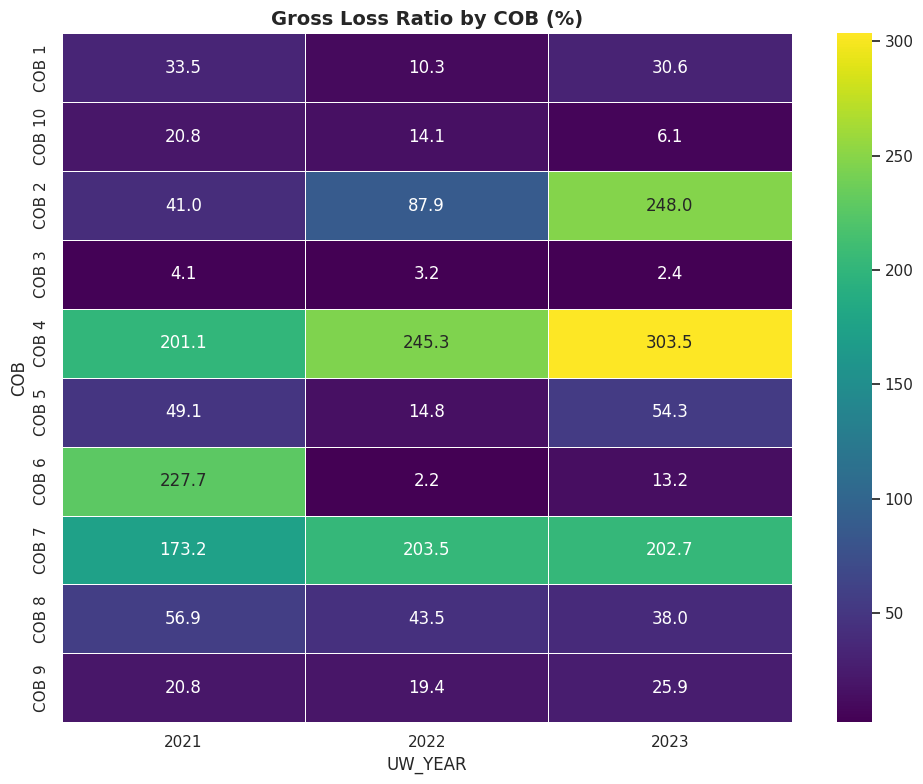

In [ ]:
# =====================================================
# PLOT 4
# COB HEATMAP
# =====================================================

heatmap_data = cob_lr.pivot(
    index="COB",
    columns="UW_YEAR",
    values="GROSS_LR"
)

plt.figure(figsize=(10,8))

sns.heatmap(
    heatmap_data*100,
    cmap="viridis",
    annot=True,
    fmt=".1f",
    linewidths=0.5
)

plt.title(
    "Gross Loss Ratio by COB (%)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

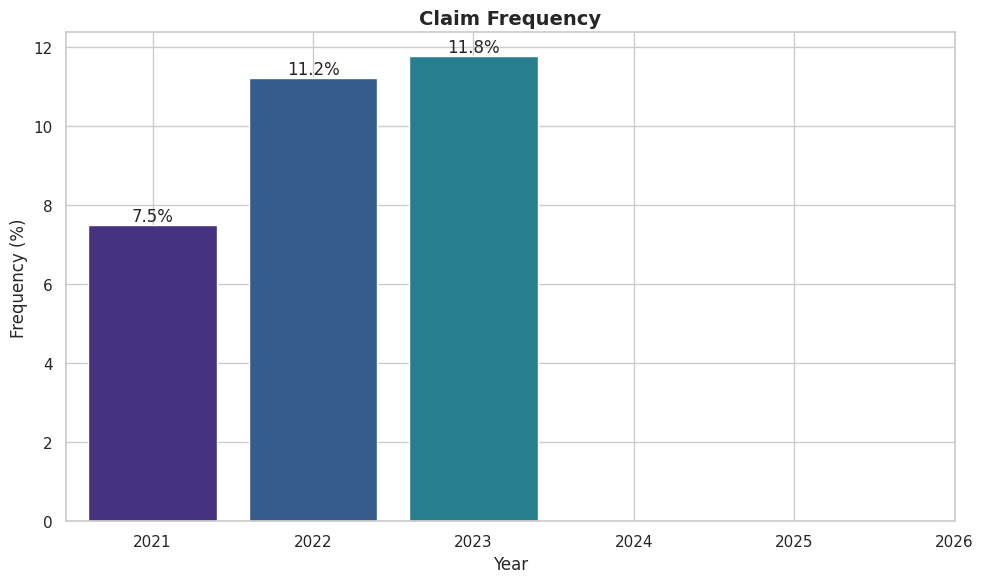

In [ ]:
# =====================================================
# PLOT 5
# CLAIM FREQUENCY
# =====================================================

plt.figure(figsize=(10,6))

bars = plt.bar(
    frequency_df["index"].astype(int),
    frequency_df["CLAIM_FREQUENCY"]*100,
    color=viridis_6
)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom"
    )

plt.xticks(
    frequency_df["index"].astype(int)
)

plt.title(
    "Claim Frequency",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Frequency (%)")

plt.tight_layout()
plt.show()

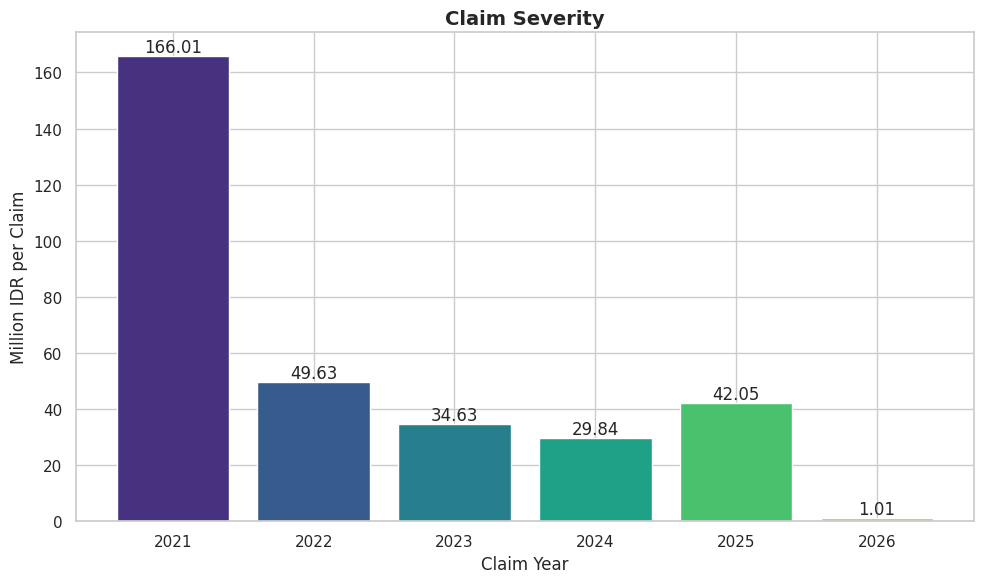

In [ ]:
# =====================================================
# PLOT 6
# CLAIM SEVERITY
# =====================================================

plt.figure(figsize=(10,6))

bars = plt.bar(
    claim_trend["CLM_YEAR"].astype(int),
    claim_trend["CLAIM_SEVERITY"]/1e6,
    color=viridis_6
)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom"
    )

plt.xticks(
    claim_trend["CLM_YEAR"].astype(int)
)

plt.title(
    "Claim Severity",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Claim Year")
plt.ylabel("Million IDR per Claim")

plt.tight_layout()
plt.show()

In [ ]:
premium, claim = load_data(FILE_PATH)

premium, claim = create_derived_variables(
    premium,
    claim
)

premium_trend = premium_trend_analysis(
    premium
)

claim_trend = claim_trend_analysis(
    claim
)

frequency_df = claim_frequency_analysis(
    premium,
    claim
)

lr = loss_ratio_analysis(
    premium_trend,
    claim_trend
)

cob_lr = cob_loss_ratio_analysis(
    premium,
    claim
)

validation_tables(
    premium_trend,
    claim_trend,
    lr
)

generate_insights(
    lr,
    claim_trend
)




PREMIUM SUMMARY
   UW_YEAR  GWP_IDR  RWP_IDR  NWP_IDR  POLICY_COUNT  CESSION_RATE  GWP_YOY
0     2021   855.57   187.78   667.79         47481          0.22      NaN
1     2022   814.13   180.61   633.52         56890          0.22    -0.05
2     2023   841.02   178.20   662.81         52958          0.21     0.03

CLAIM SUMMARY
   CLM_YEAR  GROSS_INCURRED  NET_INCURRED  CLAIM_COUNT  CLAIM_SEVERITY
0      2021          590.99        560.93         3560            0.17
1      2022          316.71        293.28         6381            0.05
2      2023          216.21        199.58         6243            0.03
3      2024          105.62         87.47         3540            0.03
4      2025            9.21          8.35          219            0.04
5      2026            0.15          0.15          144            0.00

LOSS RATIO
   UW_YEAR  GROSS_LR  NET_LR
0     2021     69.08   84.00
1     2022     38.90   46.29
2     2023     25.71   30.11

===== INSIGHTS =====
Worst UW Year: 2021
B